# Model Training — Citibike Demand Forecasting
XGBoost regression: predict hourly trip count per station.

In [1]:
import sys
from pathlib import Path
from dotenv import load_dotenv
load_dotenv(Path('../.env'))

sys.path.append('../src')

#!pip install joblib
#!pip install scikit-learn

#!{sys.executable} -m pip install xgboost


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

from features import fetch_features, get_feature_columns, get_target_column

In [2]:
# Load data — more rows than EDA for better training signal
df = fetch_features(limit=200000)
print(f'Loaded: {df.shape}')
df.head()

/Users/aditya/transit-Analytics/dbt-env/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded: (200000, 8)


,start_station_id,year,month,day,day_of_week,hour,is_weekend,trip_count
0,72,2013,7,1,2,1,0,1
1,72,2013,7,1,2,5,0,2
2,72,2013,7,1,2,6,0,1
3,72,2013,7,1,2,8,0,9
4,72,2013,7,1,2,9,0,4


In [3]:
# Split features and target
feature_cols = get_feature_columns()
target_col = get_target_column()

X = df[feature_cols]
y = df[target_col]

print('Features:', feature_cols)
print('Target:  ', target_col)
print(f'X: {X.shape}  y: {y.shape}')

Features: ['month', 'day', 'day_of_week', 'hour', 'is_weekend']
Target:   trip_count
X: (200000, 5)  y: (200000,)


In [4]:
# Train / test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Train: (160000, 5)  Test: (40000, 5)


In [5]:
# Train XGBoost
model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
print('Training complete.')

[0]	validation_0-rmse:5.82992
[50]	validation_0-rmse:5.08866
[100]	validation_0-rmse:5.02985
[150]	validation_0-rmse:5.01366
[200]	validation_0-rmse:5.00628
[250]	validation_0-rmse:5.00069
[299]	validation_0-rmse:4.99735
Training complete.


In [6]:
# Evaluate
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.2f} trips')
print(f'RMSE: {rmse:.2f} trips')
print(f'R2:   {r2:.4f}')

MAE:  3.42 trips
RMSE: 5.00 trips
R2:   0.2791


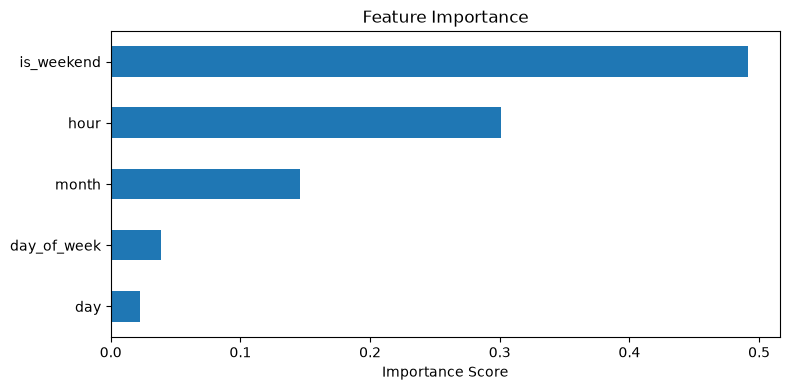

In [7]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importance.plot(kind='barh')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [8]:
# Save model
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/citibike_demand_model.joblib')
print('Model saved to ../models/citibike_demand_model.joblib')

Model saved to ../models/citibike_demand_model.joblib
